# SALT3 Single Spectrum Fitting
This notebook allows you to load a single supernova spectrum, fit it using the SALT3 model with `dynesty`, and visualize the results including convergence plots, corner plots, and the best-fit model compared to the data.

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot


SPECTRA_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/data/all_spectra_dereddened'
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 500

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')

## 1. Helper Functions

In [46]:
def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

def run_fit(wavelength, flux, flux_err, mjd_max, nlive, method='nuis', redshift=None):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)
    
    if method == 'full':
        params = ['t0', 'x1', 'c', 'log10_x0']
        priors = {'t0': (-30, 30), 'x1': (-4, 4), 'c': (-0.4, 1.5), 'log10_x0': (-20, -2)}
    else:
        params = ['t0', 'x1', 'c']
        priors = {'t0': (-30, 30), 'x1': (-4, 4), 'c': (-0.4, 1.5)}

    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    def ll(t):
        p_dict = dict(zip(params, t))
        if 'log10_x0' in p_dict: p_dict['x0'] = 10**p_dict.pop('log10_x0')
        model.set(**p_dict)
        try:
            if method == 'nuis':
                model.set(x0=1.0)
                m_flux_unit = model.flux(0.0, wavelength)
                w = 1.0 / flux_err**2
                num, den = np.sum(flux * m_flux_unit * w), np.sum(m_flux_unit**2 * w)
                if den <= 0: return -1e10
                x0_best = num / den
                if x0_best <= 0: return -1e10
                chisq = np.sum(((flux - x0_best * m_flux_unit) / flux_err)**2)
            else:
                m_flux = model.flux(0.0, wavelength)
                chisq = np.sum(((flux - m_flux) / flux_err)**2)
            return -0.5 * chisq if not np.isnan(chisq) else -1e10
        except: return -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rwalk')
    sampler.run_nested()
    return sampler.results, params

In [47]:
def run_fit2(wavelength, flux, flux_err, mjd_obs, nlive, redshift=None):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)

    # Parameter setup
    params = ['t0', 'x1', 'c']
    priors = {'t0': (-30, 30), 'x1': (-4, 4), 'c': (-1, 1)}

    # Prior transform
    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    # Loglikehood function
    def ll(t):
        # unpacking
        p_dict = dict(zip(params, t))

        # setting up t0 as an offset
        t0_offset = p_dict.pop('t0')
        t0_mjd = mjd_obs - (t0_offset * (1 + redshift))

        # model setup
        model.set(t0 = t0_mjd)
        model.set(**p_dict)
        model.set(x0=1.0)

        # setup the flux with a x0 of 1
        m_flux_unit = model.flux(mjd_obs, wavelength)

        # setup the weights for the fluxes
        w = 1.0 / flux_err**2

        # setting up the numerator and denominator of the weighted least squares minimization
        num, den = np.sum(flux * m_flux_unit * w), np.sum(m_flux_unit**2 * w)

        # finding the best x0 scaling parameter
        if den <= 0: return -1e10
        x0_best = num / den
        if x0_best <= 0: return -1e10

        #
        chisq = np.sum(((flux - x0_best * m_flux_unit) / flux_err)**2)


        return -0.5 * chisq if not np.isnan(chisq) else -1e10


    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rslice')
    sampler.run_nested()
    return sampler.results, params

## 2. Load Data
Select a spectrum from the `data/all_spectra` directory.

Found metadata for sn1999ef-19991016.30-fast.flm: z=0.0393, mjd_max=51467.3
True Phase: 9.62 d
SNID Phase: 10.60 d
Subtype: N


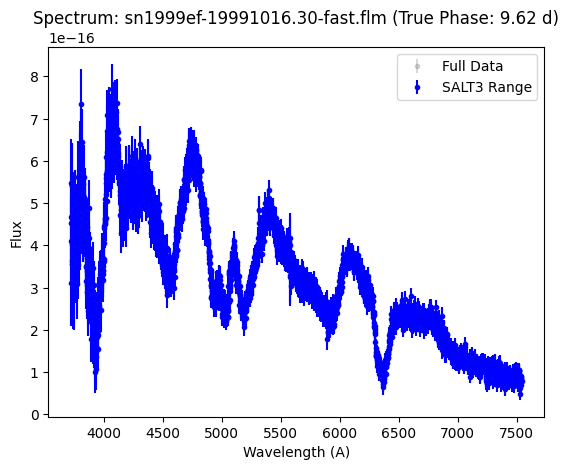

0.0393


In [48]:
# Example file
FILENAME = 'sn1999ef-19991016.30-fast.flm'

# Get params from SNID results
true_phase = None
snid_phase = None
mjd_max = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]
        mjd_max = row['MJD'].values[0]
        z = row['redshift'].values[0]


if mjd_max is not None:
    print(f"Found metadata for {FILENAME}: z={z}, mjd_max={mjd_max}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

print(z)

## 3. Run Nested Sampling

In [49]:
results, params_names = run_fit2(wave_f, flux_f, err_f, mjd_max, NLIVE, redshift=z)
print("Fit complete.")

iter: 8373 | +500 | bound: 69 | nc: 1 | ncall: 225197 | eff(%):  3.949 | loglstar:   -inf < -1685.943 <    inf | logz: -1701.905 +/-  1.358 | dlogz:  0.001 >  0.509                                  

Fit complete.


## 4. Convergence Plots
Check if the evidence has converged and look at the parameter traces.

/Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


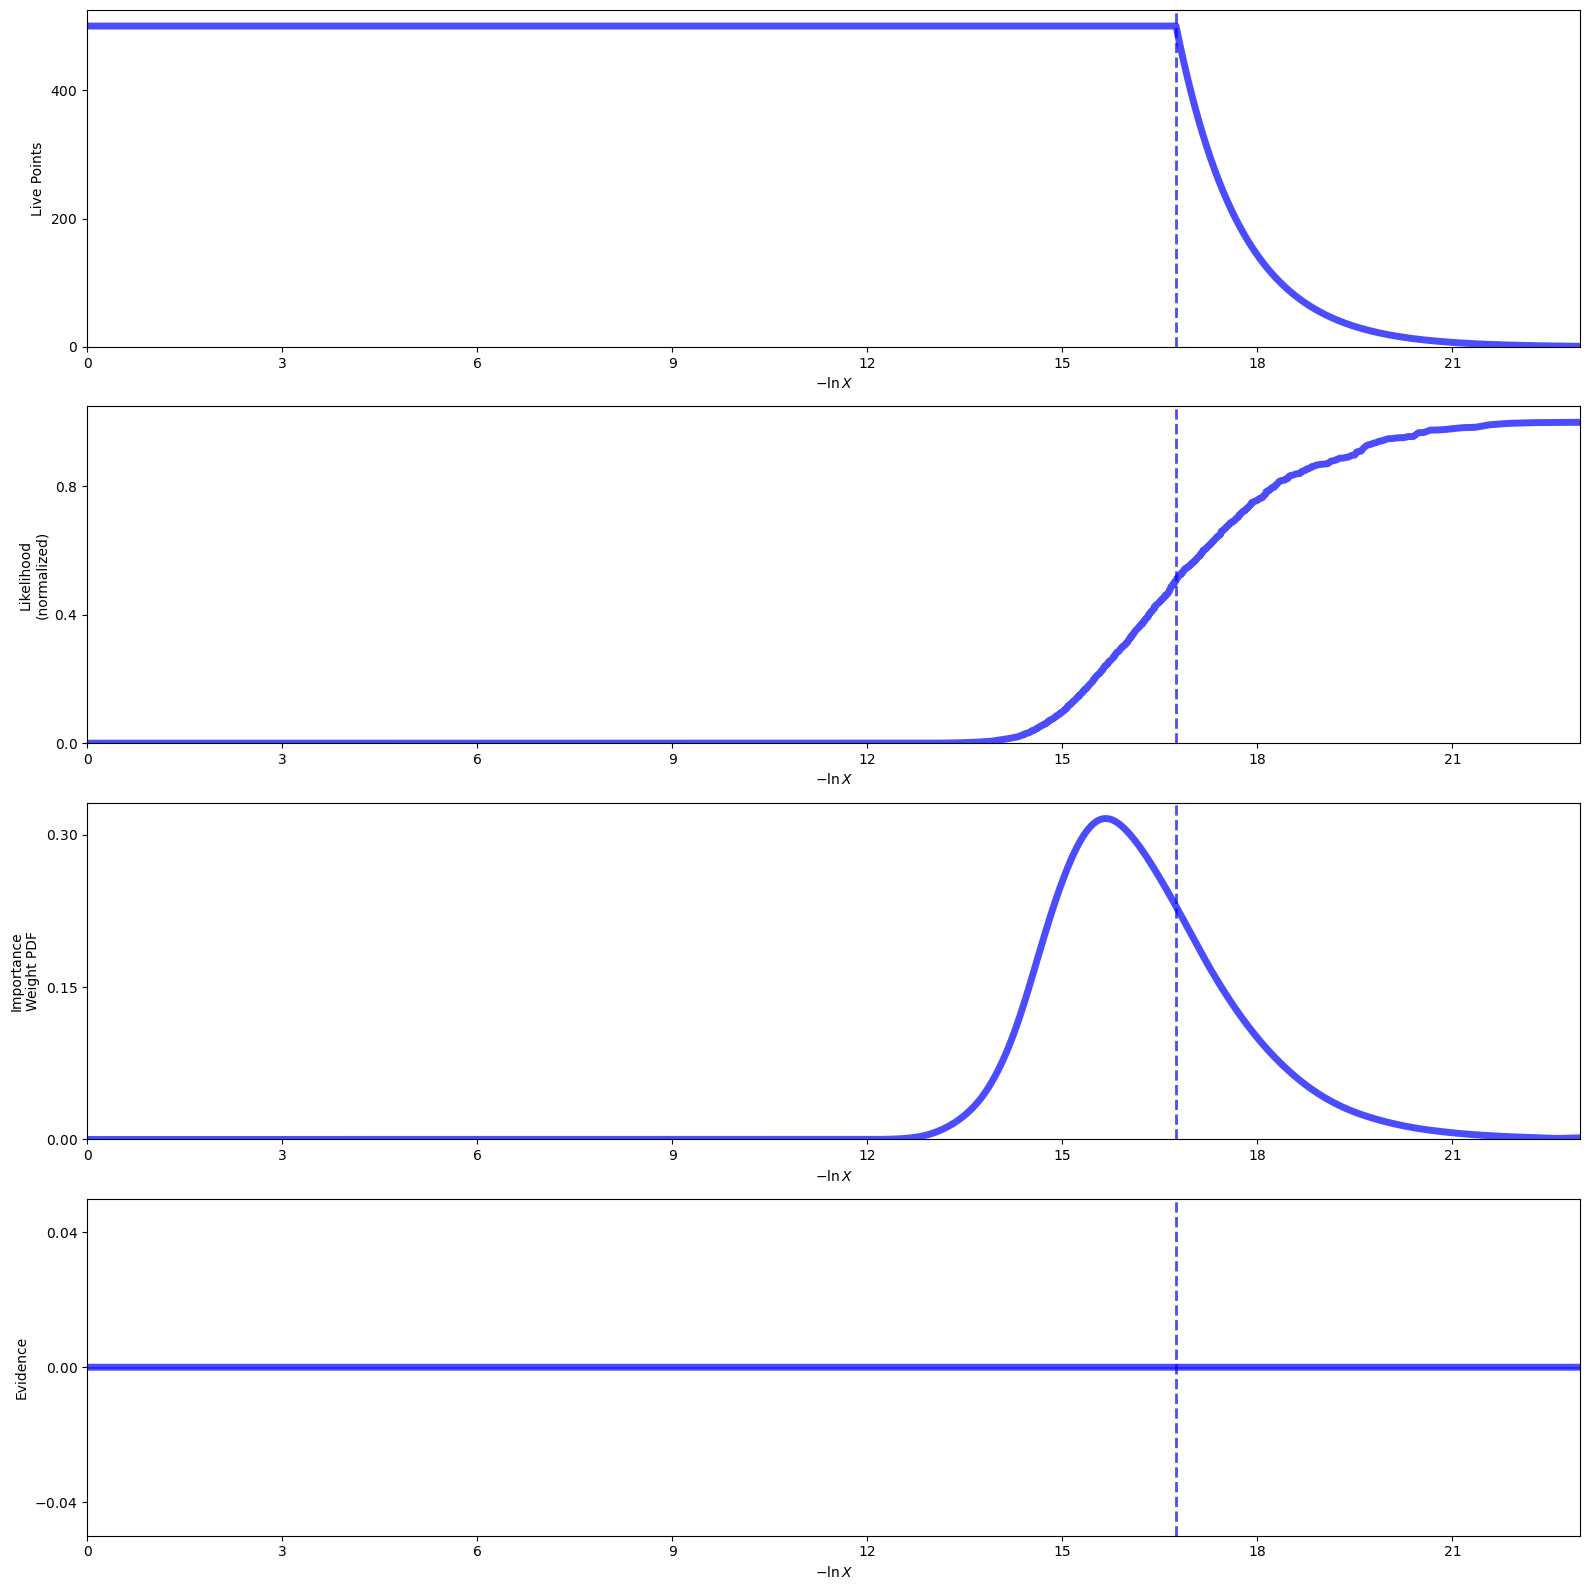

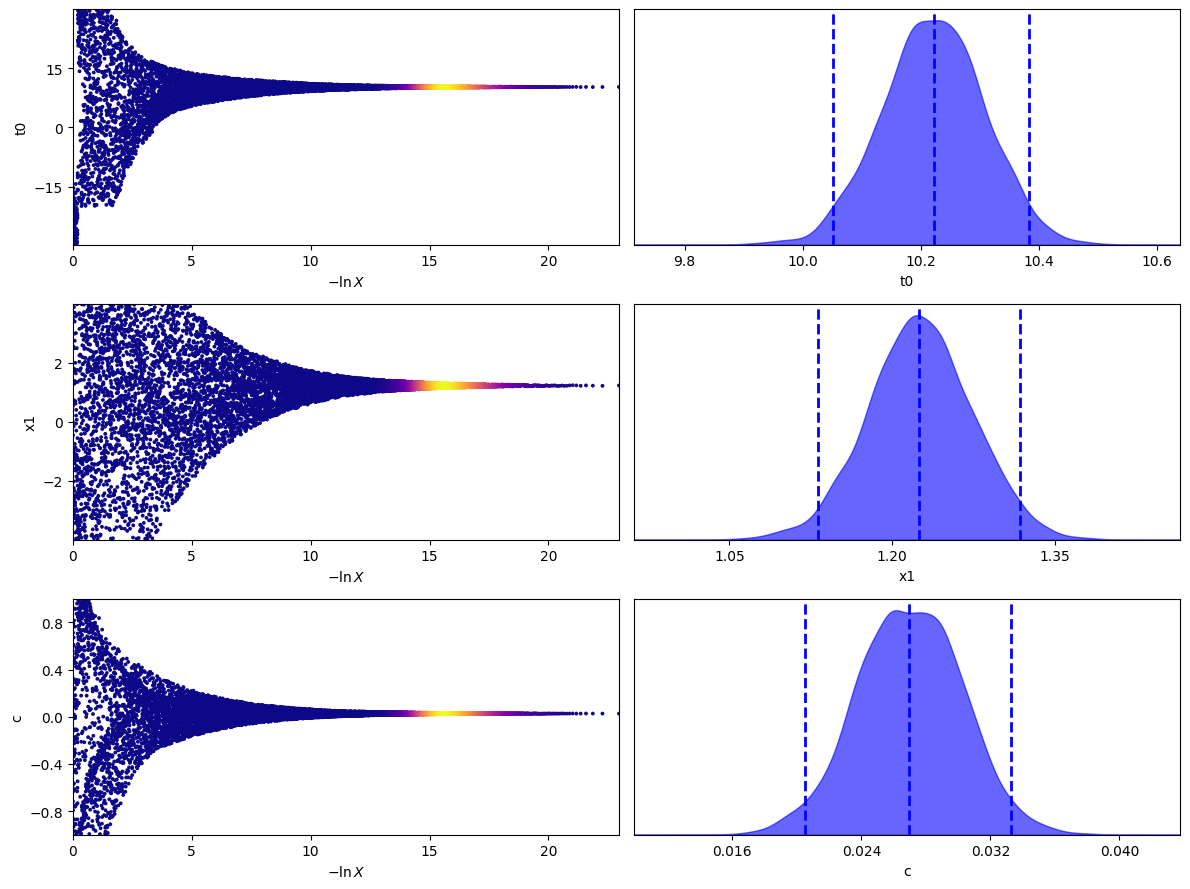

In [50]:
fig, axes = dyplot.runplot(results)
plt.tight_layout()
plt.show()

fig, axes = dyplot.traceplot(results, labels=params_names)
plt.tight_layout()
plt.show()

## 5. Corner Plot
Visualize parameter correlations and marginalized distributions.

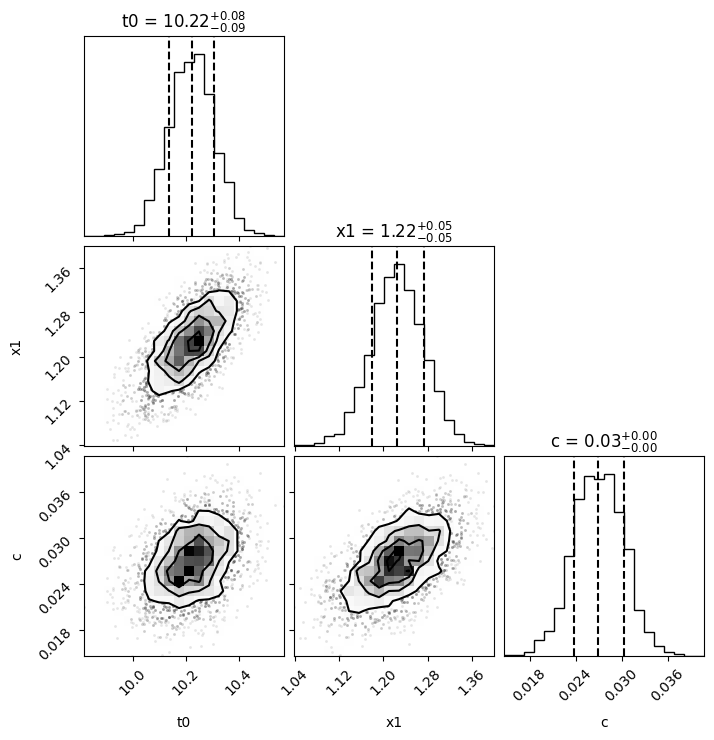

In [51]:
# Resample for equal weights
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

fig = corner.corner(samples, labels=params_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

## 6. Model vs Data
Overlay the best-fit model on the observed spectrum.

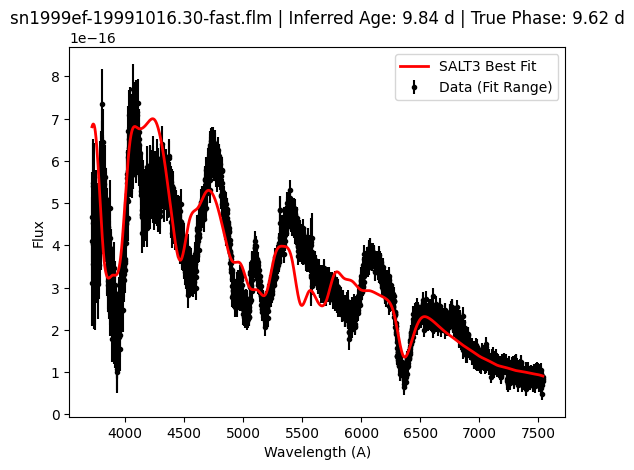

In [52]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=z)

model.set(**p_dict)
model.set(x0=1.0)
m_flux_unit = model.flux(p_dict['t0'], wave_f)
w = 1.0 / err_f**2
x0_best = np.sum(flux_f * m_flux_unit * w) / np.sum(m_flux_unit**2 * w)
model.set(x0=x0_best)
model_flux = m_flux_unit * x0_best

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit',zorder=10)

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [53]:
SNID_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfa_pipeline/all_spectra_dereddened_snidded_supersnid'

# The number of the comp file we want to pick
no = '01'

base_filename = FILENAME.rsplit('.', 1)[0]

snid_output_name = f"{base_filename}_comp00{no}_snidflux.dat"

compfile = os.path.join(SNID_DIR, snid_output_name)


compwave, compflux, comperr = load_flm_spectrum(compfile)
mask = (compwave > 3500) & (compwave < 8000)
compwave_f, compflux_f, comperr_f = compwave[mask], compflux[mask], comperr[mask]


In [54]:
# print(compwave_f, compflux_f, comperr_f)

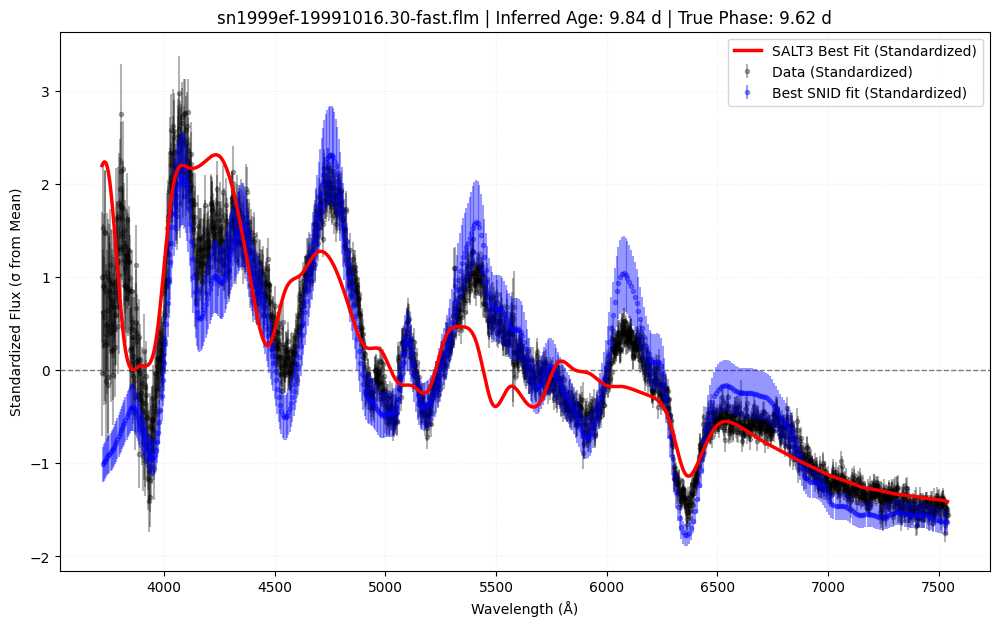

In [55]:
import numpy as np

# --- Standardized Normalization (Zero Mean, Unit Variance) ---
def standardize(flux, error=None):
    f_mean = np.mean(flux)
    f_std = np.std(flux)

    # Center at zero and scale so 'wiggles' have comparable amplitude
    norm_flux = (flux - f_mean) / f_std

    if error is not None:
        # Errors must be scaled by the same factor to maintain SNR
        norm_error = error / f_std
        return norm_flux, norm_error
    return norm_flux

# Process all three datasets
flux_f_norm, err_f_norm = standardize(flux_f, err_f)
model_flux_norm = standardize(model_flux)
compflux_f_norm, comperr_f_norm = standardize(compflux_f, comperr_f)
# -----------------------------------------------------------

plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f_norm, yerr=err_f_norm, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux_norm, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# 3. SNID Fit (Blue dots/line)
plt.errorbar(compwave_f, compflux_f_norm, yerr=comperr_f_norm, fmt='.', color='blue',
             alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0']) / (1 + z)
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()